In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Question 1: Apply Normalisation and Standardization on column 1-3.

Wine CSV

In [2]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datascience Lab3/wine_data.csv', header=None, usecols=[1,2,3])
df.head()

,1,2,3
0,14.23,1.71,2.43
1,13.20,1.78,2.14
2,13.16,2.36,2.67
3,14.37,1.95,2.50
4,13.24,2.59,2.87


In [3]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm='l2')
normalized_data = normalizer.transform(df.values)
normalized_data = pd.DataFrame(normalized_data)
normalized_data.head()

,0,1,2
0,0.978887,0.117632,0.167161
1,0.978481,0.131947,0.158633
2,0.965239,0.173098,0.195835
3,0.976514,0.132512,0.169888
4,0.959918,0.187779,0.208079


In [4]:
from sklearn.preprocessing import StandardScaler

standardizer = StandardScaler()
standardized_data = standardizer.fit_transform(df.values)
standardized_data = pd.DataFrame(standardized_data)
standardized_data.head()

,0,1,2
0,1.518613,-0.562250,0.232053
1,0.246290,-0.499413,-0.827996
2,0.196879,0.021231,1.109334
3,1.691550,-0.346811,0.487926
4,0.295700,0.227694,1.840403


#### Question 2: Try to identify categorical/discrete data and encode it.

Heart CSV

In [5]:
df = pd.read_csv(filepath_or_buffer='/content/drive/MyDrive/Colab Notebooks/datascience Lab3/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
for col in df.columns:
    unique_count = df[col].nunique()
    total_count = len(df[col])
    print(f"{col:<20} : {unique_count:>5} unique values ({(unique_count / total_count * 100):>6.2f}%)")

age                  :    41 unique values ( 13.53%)
sex                  :     2 unique values (  0.66%)
cp                   :     4 unique values (  1.32%)
trestbps             :    49 unique values ( 16.17%)
chol                 :   152 unique values ( 50.17%)
fbs                  :     2 unique values (  0.66%)
restecg              :     3 unique values (  0.99%)
thalach              :    91 unique values ( 30.03%)
exang                :     2 unique values (  0.66%)
oldpeak              :    40 unique values ( 13.20%)
slope                :     3 unique values (  0.99%)
ca                   :     5 unique values (  1.65%)
thal                 :     4 unique values (  1.32%)
target               :     2 unique values (  0.66%)


In [7]:
# By looking at above values
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

# Other columsn are continuous in nature.
# Now create new column.
df_new = df[categorical_cols]
df_new.head()

,sex,cp,fbs,restecg,exang,slope,ca,thal,target
0,1,3,1,0,0,0,0,1,1
1,1,2,0,1,0,0,0,2,1
2,0,1,0,0,0,2,0,2,1
3,1,1,0,1,0,2,0,2,1
4,0,0,0,1,1,2,0,2,1


In [8]:
df_new.nunique()

,0
sex,2
cp,4
fbs,2
restecg,3
exang,2
slope,3
ca,5
thal,4
target,2


In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Other categories have binary labels, hence one hot encode other columns
onehot_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(), onehot_cols)],
    remainder='passthrough'
)

df_transformed = ct.fit_transform(df_new)

encoded_feature_names = ct.get_feature_names_out()

df = pd.DataFrame(df_transformed, columns=encoded_feature_names)
df

,encoder__cp_0,encoder__cp_1,encoder__cp_2,encoder__cp_3,encoder__restecg_0,encoder__restecg_1,encoder__restecg_2,encoder__slope_0,encoder__slope_1,encoder__slope_2,...,encoder__ca_3,encoder__ca_4,encoder__thal_0,encoder__thal_1,encoder__thal_2,encoder__thal_3,remainder__sex,remainder__fbs,remainder__exang,remainder__target
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
299,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
300,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
301,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


#### Question 3: Find out the column with missing values (NA) and identify the ratio of missing values.

Weather Australia

In [10]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datascience Lab3/weatherAUS.csv')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [11]:
column_name = df.columns
total_rows = len(df)
missing_value_count = df.isnull().sum().values

missing_value_ratio = (missing_value_count/total_rows)*100
pd.DataFrame({'Column':column_name, 'Missing value ratios': missing_value_ratio})

,Column,Missing value ratios
0,Date,0.000000
1,Location,0.000000
2,MinTemp,1.020899
3,MaxTemp,0.866905
4,Rainfall,2.241853
5,Evaporation,43.166506
6,Sunshine,48.009762
7,WindGustDir,7.098859
8,WindGustSpeed,7.055548
9,WindDir9am,7.263853


#### Question 4: Apply mean, median and mode imputation based on the column type. Observe the changes after imputation. Use simple plot.

Weather Australia

In [12]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datascience Lab3/weatherAUS.csv')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [13]:
# Segregate the feature types
# Dropped Location and Date as there are no missing values
categorical_cols = [
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
    "Cloud9am",
    "Cloud3pm",
    "RainToday",
    "RainTomorrow"
]

continuous_cols = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Evaporation",
    "Sunshine",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Temp9am",
    "Temp3pm"
]

In [14]:
# | Type        | Imputation method    |
# | ----------- | -------------------- |
# | Numerical   | Mean or Median       |
# | Categorical | Mode                 |

In [15]:
df_cat = df[categorical_cols].copy()
missing_before = df_cat.isna().sum()

# Filling missing values with mode
for col in categorical_cols:
    mode_val = df_cat[col].mode()[0]
    df_cat[col + "_imputed"] = df_cat[col].fillna(mode_val)

df_cat.head()

,WindGustDir,WindDir9am,WindDir3pm,Cloud9am,Cloud3pm,RainToday,RainTomorrow,WindGustDir_imputed,WindDir9am_imputed,WindDir3pm_imputed,Cloud9am_imputed,Cloud3pm_imputed,RainToday_imputed,RainTomorrow_imputed
0,W,W,WNW,8.0,NaN,No,No,W,W,WNW,8.0,7.0,No,No
1,WNW,NNW,WSW,NaN,NaN,No,No,WNW,NNW,WSW,7.0,7.0,No,No
2,WSW,W,WSW,NaN,2.0,No,No,WSW,W,WSW,7.0,2.0,No,No
3,NE,SE,E,NaN,NaN,No,No,NE,SE,E,7.0,7.0,No,No
4,W,ENE,NW,7.0,8.0,No,No,W,ENE,NW,7.0,8.0,No,No


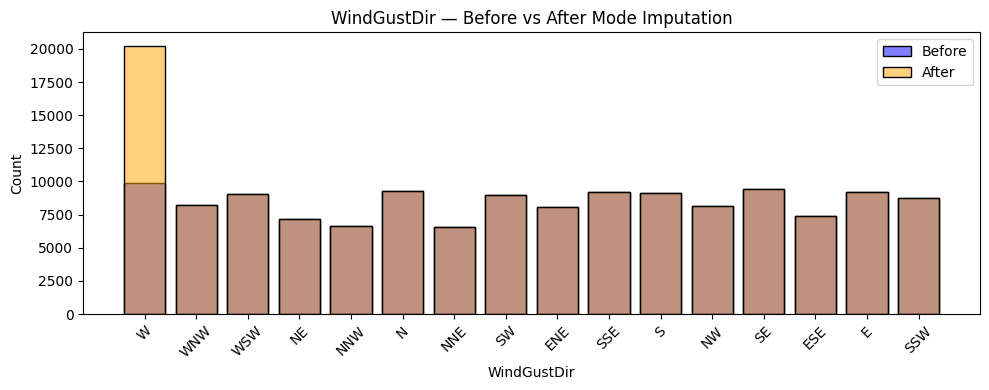

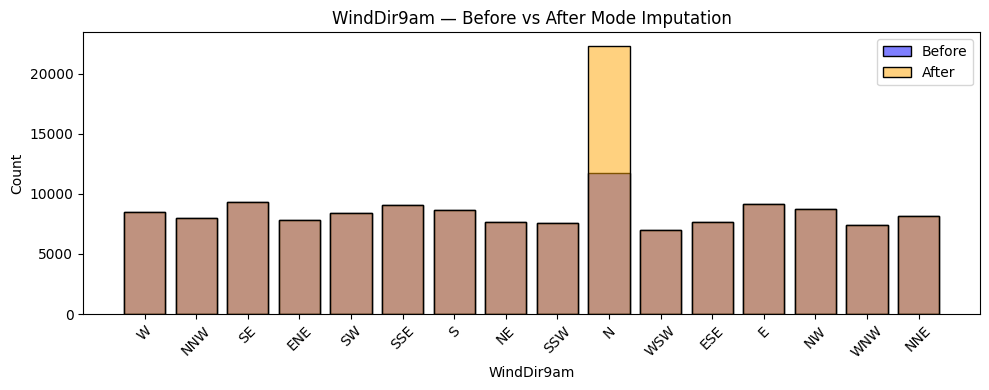

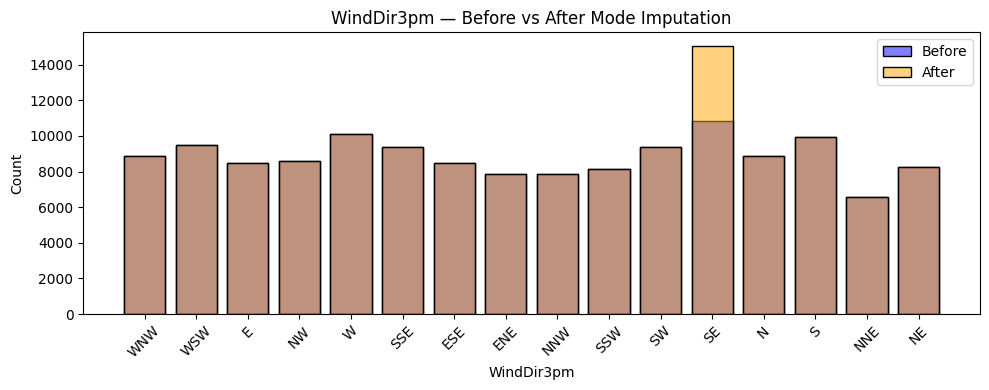

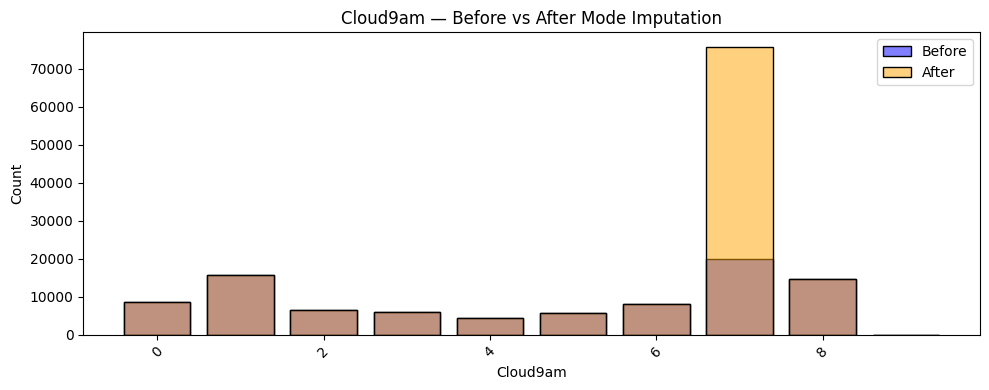

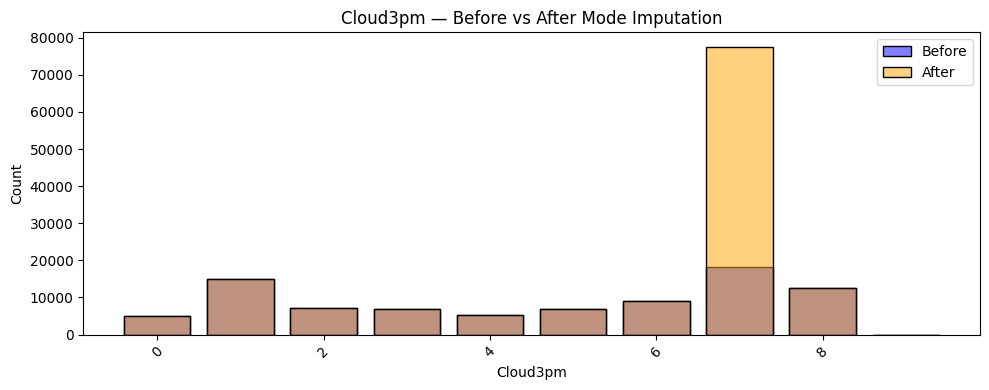

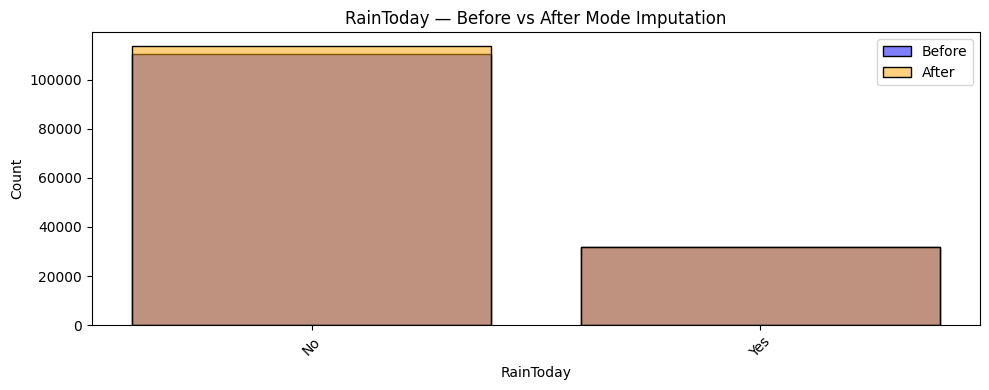

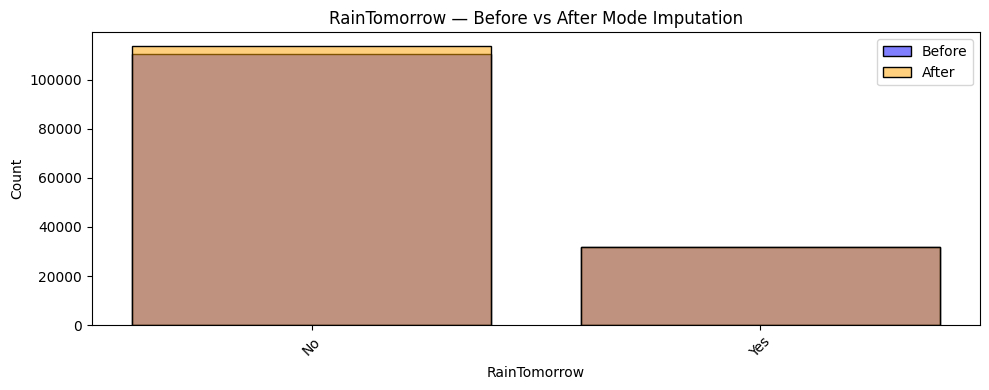

In [16]:
for col in categorical_cols:
    plt.figure(figsize=(10, 4))

    sns.histplot(df_cat[col], color="blue", label="Before", multiple="dodge", shrink=0.8,
                 stat="count", discrete=True, alpha=0.5)

    sns.histplot(df_cat[col + "_imputed"], color="orange", label="After", multiple="dodge", shrink=0.8,
                 stat="count", discrete=True, alpha=0.5)

    plt.title(f"{col} — Before vs After Mode Imputation")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [17]:
df_cont = df[continuous_cols].copy()

for col in continuous_cols:
  # we can choose mean also here
  median_val = df_cont[col].median()
  df_cont[col + "_imputed"] = df_cont[col].fillna(median_val)

df_cont.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Sunshine_imputed,WindGustSpeed_imputed,WindSpeed9am_imputed,WindSpeed3pm_imputed,Humidity9am_imputed,Humidity3pm_imputed,Pressure9am_imputed,Pressure3pm_imputed,Temp9am_imputed,Temp3pm_imputed
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,...,8.4,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,...,8.4,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,...,8.4,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,...,8.4,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,...,8.4,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7


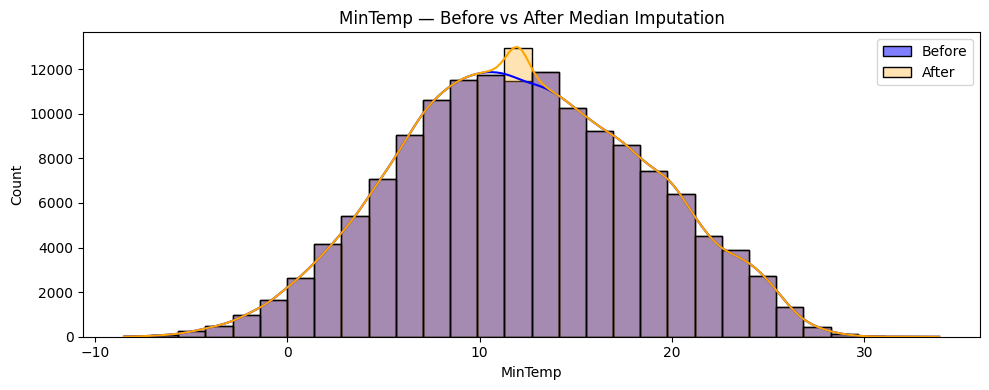

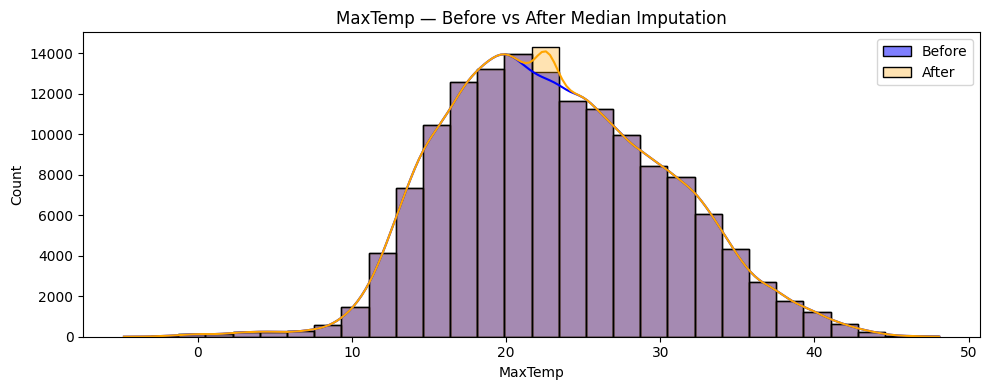

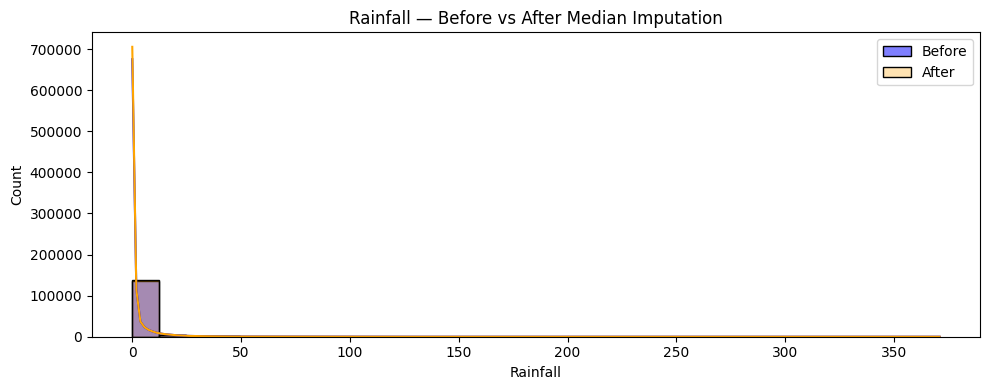

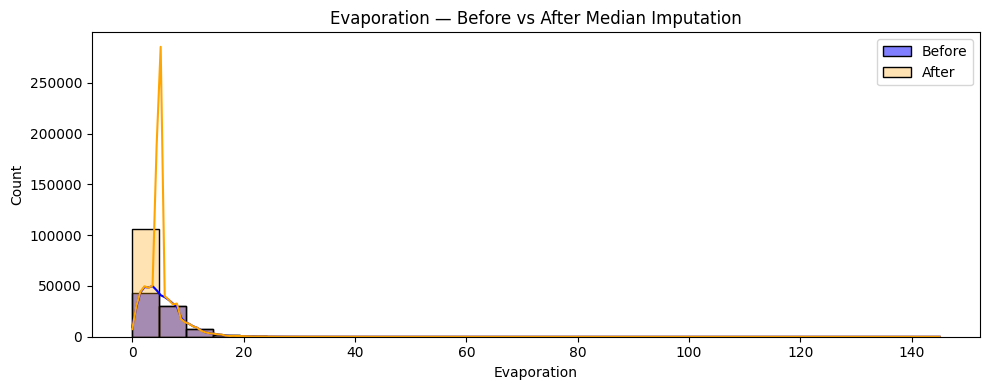

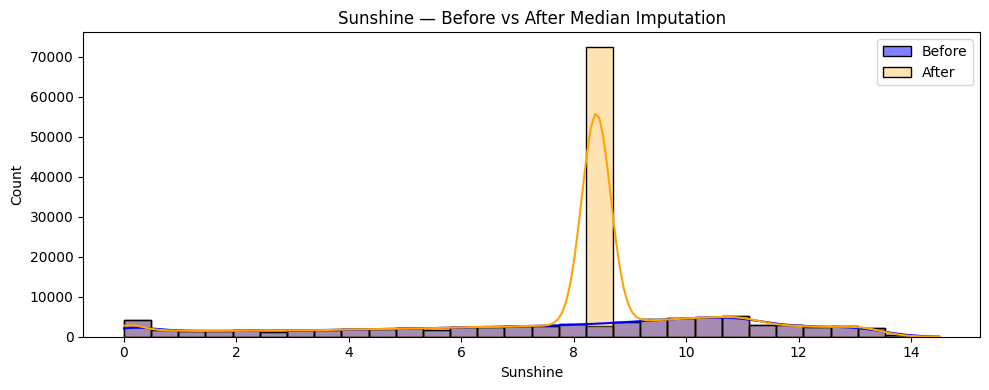

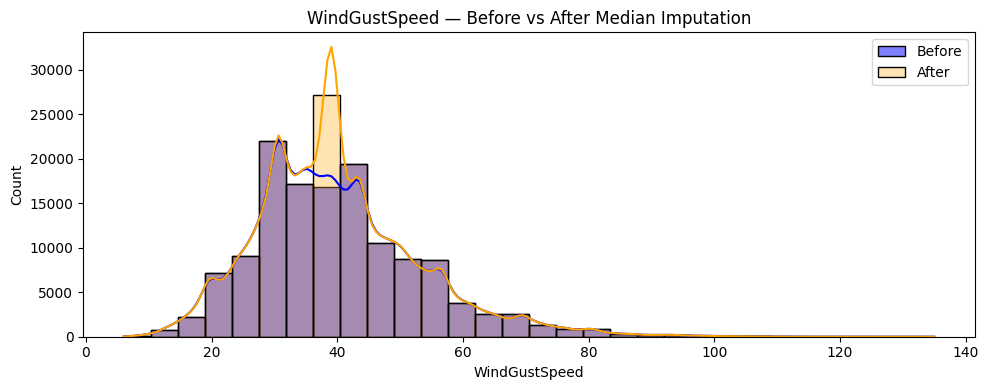

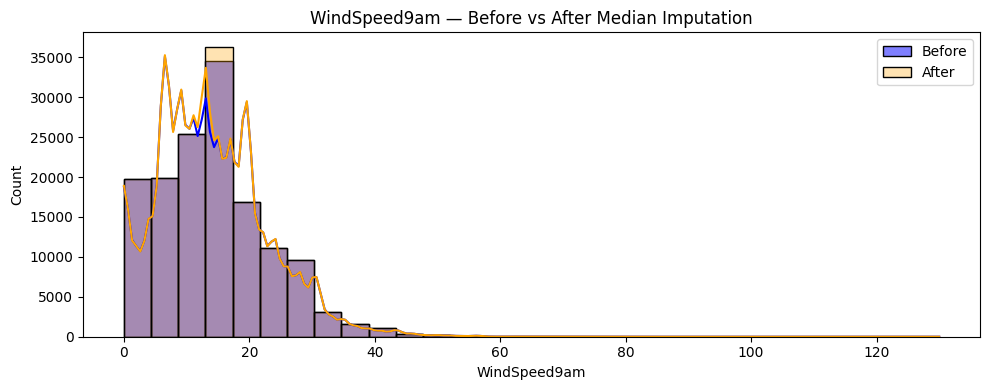

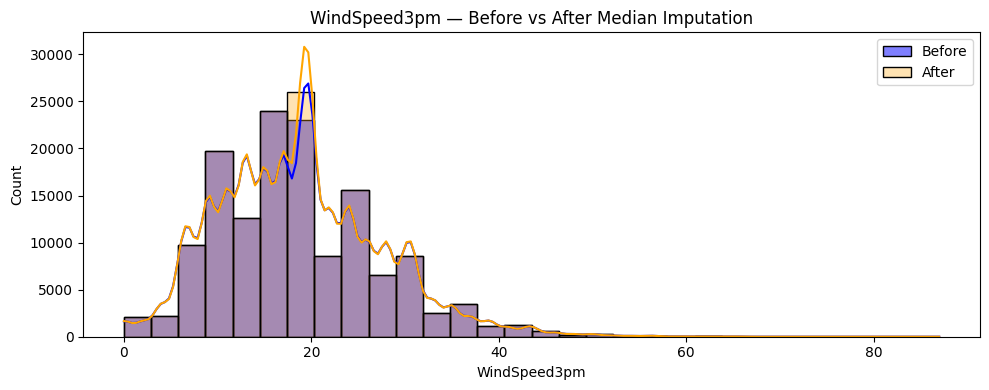

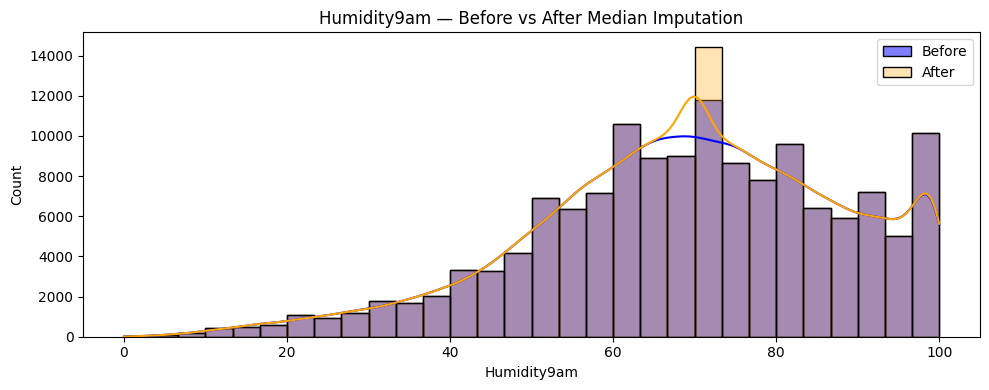

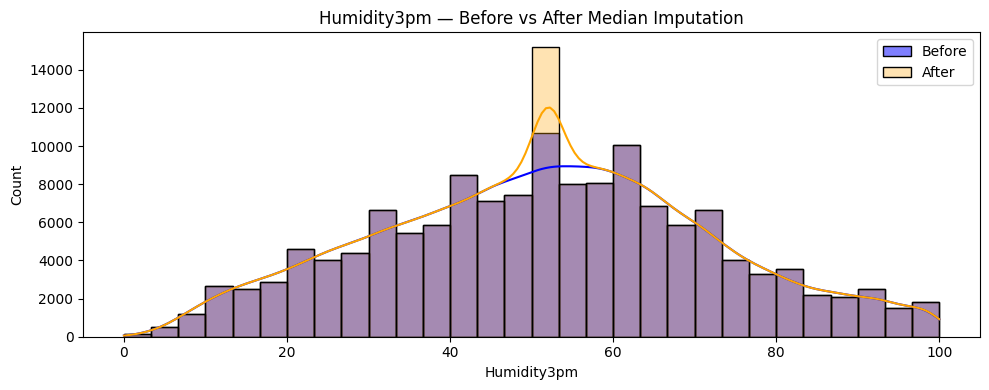

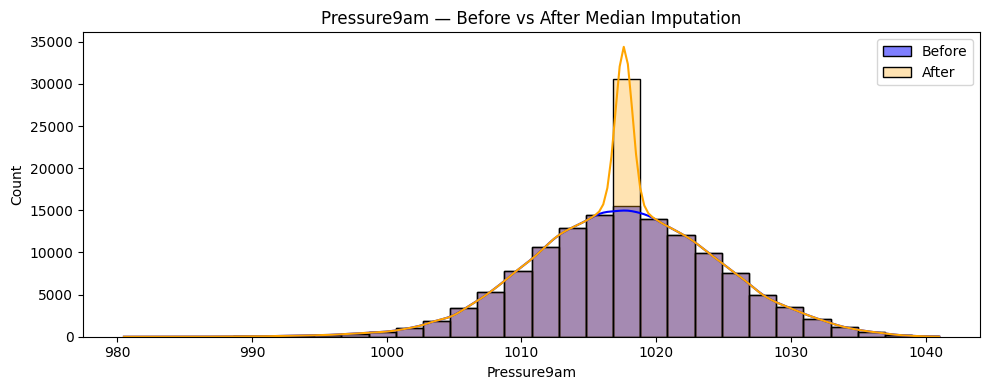

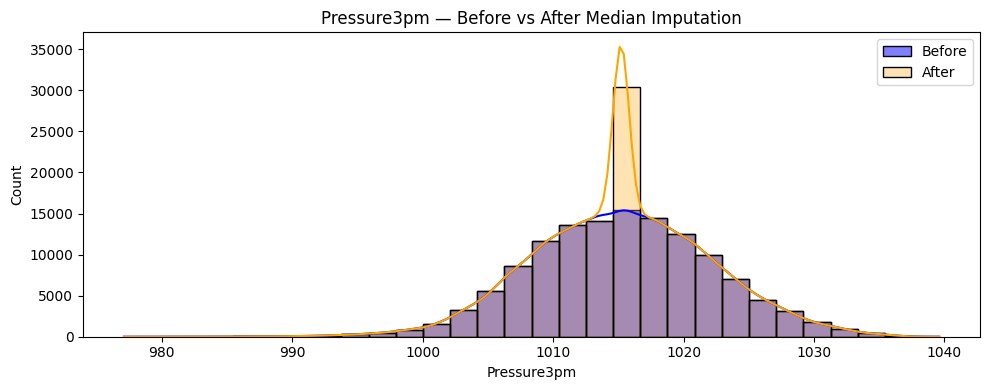

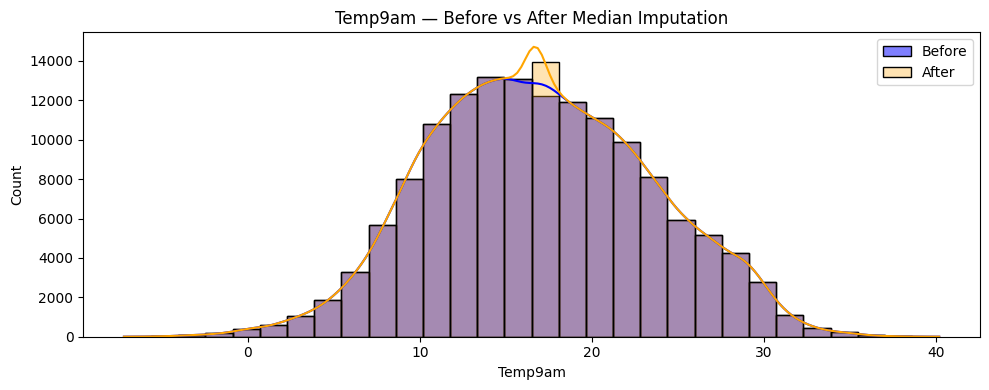

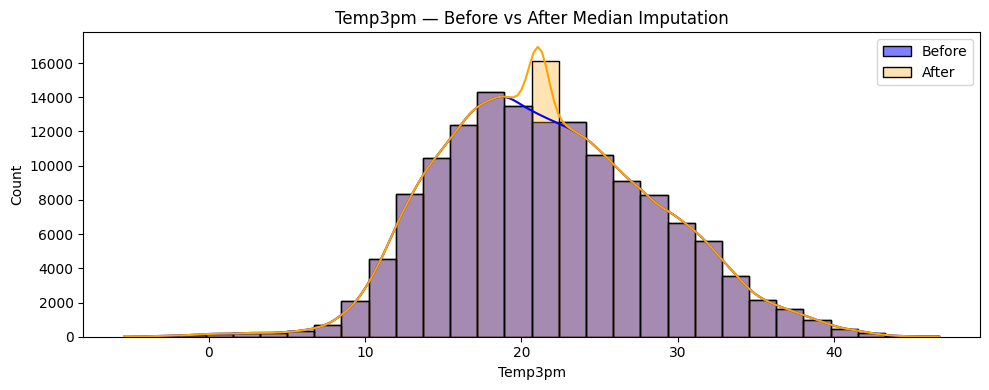

In [18]:
for col in continuous_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(df_cont[col], kde=True, color="blue", label="Before", bins=30)
    sns.histplot(df_cont[col + "_imputed"], kde=True, color="orange", label="After", bins=30, alpha=0.3)
    plt.title(f"{col} — Before vs After Median Imputation")
    plt.legend()
    plt.tight_layout()
    plt.show()
